# Agent RAG 代码说明

这个 notebook 实现的是一个带检索工具的 RAG Agent。整体执行路径是：用户问题 -> LLM 判断是否需要检索 -> 调用 retriever 工具 -> 把检索结果交回 LLM -> LLM 生成最终回答。

下面的代码注释会重点解释三件事：状态 `AgentState` 如何保存消息、工具调用如何发生、LangGraph 如何让 `llm` 和 `retriever_agent` 两个节点循环协作。


In [1]:
# ===== 1. 导入依赖并加载环境变量 =====
# 这一格主要做准备工作：导入后面需要的库，并把 .env 里的 API Key 加载进环境变量。

# os 用来读取环境变量，例如 OPENAI_API_KEY、OPENAI_BASE_URL。
import os
# Path 用来处理 .env 路径，让 notebook 从不同目录启动时都能找到配置文件。
from pathlib import Path
# operator.add 本质上就是列表相加。
# 在 AgentState 里把它命名为 add_messages，是为了表达“把新消息追加到旧消息后面”。
# 注意：这里用的是 operator.add，不是 langgraph.graph.message.add_messages。
# 对当前代码来说，它的效果是：old_messages + new_messages。
from operator import add as add_messages
# Annotated 可以给类型额外绑定 reducer；Sequence 表示消息序列；TypedDict 用来定义 state 结构。
from typing import Annotated, Sequence, TypedDict

# load_dotenv 会读取 .env 文件，把里面的 KEY=VALUE 写入环境变量。
from dotenv import load_dotenv
# Chroma 是向量数据库，用来保存 PDF 文本块对应的 embedding。
from langchain_chroma import Chroma
# PyPDFLoader 负责读取 PDF，并把每页内容转换成 LangChain Document。
from langchain_community.document_loaders import PyPDFLoader
# 这些 Message 类型是 LangChain/LangGraph 对话状态的基本单位。
# HumanMessage：用户输入；SystemMessage：系统指令；AIMessage：模型输出；ToolMessage：工具结果。
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
# @tool 可以把普通 Python 函数变成 LLM 可调用工具。
from langchain_core.tools import tool
# ChatOpenAI 是聊天模型；OpenAIEmbeddings 是文本向量模型。
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# RecursiveCharacterTextSplitter 用来把长文档切成适合检索的小块。
from langchain_text_splitters import RecursiveCharacterTextSplitter
# StateGraph 是 LangGraph 的核心图对象；END 表示流程结束。
from langgraph.graph import END, StateGraph

# 兼容两种启动方式：
# 1. 如果你在 langgraph_quickstart 目录里打开 notebook，就读取当前目录的 .env。
# 2. 如果你在项目根目录 /home/lee/langchain_study 打开 notebook，就读取 langgraph_quickstart/.env。
# 这样做的好处是：不管从哪个目录启动 Jupyter，代码都更容易找到 API 配置。
env_path = Path(".env")
if not env_path.exists():
    env_path = Path("langgraph_quickstart/.env")

# 加载 .env。成功后，后面就可以用 os.getenv("OPENAI_API_KEY") 读取 key。
load_dotenv(env_path)


True

In [2]:
# ===== 2. 配置 LLM、Embedding 模型和 PDF 路径 =====
# 这一格定义 RAG 需要的两个模型：
# 1. llm：负责理解问题、决定是否调用工具、最后组织答案。
# 2. embeddings：负责把 PDF 文本块转换成向量，用于相似度检索。

llm = ChatOpenAI(
    # 这里使用 OpenAI 兼容聊天模型。
    # 如果你的中转平台不支持 gpt-4o，可以换成平台支持的模型名。
    model="gpt-4o",
    # 从 .env 中读取 API Key。这里应该是你的中转服务 key 或 OpenAI key。
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    # 从 .env 中读取 base url；如果没配置，就默认使用你的 OpenAI 中转地址。
    openai_api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai-proxy.org/v1"),
    # temperature=0 表示尽量稳定、可复现。
    # RAG 问答更看重依据文档回答，不太需要很发散的创造性。
    temperature=0,
)

# Embedding 模型的作用不是聊天，而是把文本变成一串数字向量。
# 向量越相近，说明文本语义越相似；检索器就是靠这个找相关内容。
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
)

# 需要被检索的 PDF 文件。
# 注意：这是相对路径，取决于你启动 notebook 的工作目录。
pdf_path = "Stock_Market_Performance_2024.pdf"


In [3]:
# ===== 3. 加载 PDF、切分文本，并创建 Chroma 向量库 =====
# RAG 的知识库构建流程：
# PDF 文件 -> 读取成 Document -> 切成小文本块 -> 计算 embedding -> 存入 Chroma 向量库。
# 后面用户提问时，系统会在这个向量库中找最相关的文本块。

# 先检查 PDF 是否存在。
# 如果文件不存在，直接抛出清晰错误，避免后面 PyPDFLoader 报更难理解的错误。
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF 文件 {pdf_path!r} 不存在，请确保文件路径正确并且文件已存在。")

# PyPDFLoader 会读取 PDF。
# load() 后得到的 pages 是 Document 列表，通常一页对应一个 Document。
# 每个 Document 里最重要的是：page_content 文本内容，metadata 元数据。
pdf_loader = PyPDFLoader(pdf_path)

try:
    pages = pdf_loader.load()
    print(f"成功加载 PDF 文件，共 {len(pages)} 页。")
except Exception as e:
    # 如果 PDF 损坏、路径不对、依赖异常，就会进入这里。
    print(f"加载 PDF 文件时发生错误: {e}")
    raise

# 文档通常不能整篇直接塞给模型或向量库检索。
# 所以要切分成更小的 chunk，方便后续按问题检索最相关片段。
# chunk_size=1000：每个文本块大约 1000 个字符。
# chunk_overlap=200：相邻块之间重叠 200 个字符，避免重要信息刚好被切断。
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

# split_documents 会保留 Document 的 metadata，同时生成新的分块 Document 列表。
# pages_split 才是真正被存入向量库的内容。
pages_split = text_splitter.split_documents(pages)

# Chroma 的持久化目录。
# Chroma 会把向量索引和文档数据写到这里，方便之后复用。
persist_directory = r"/home/lee/langchain_study/langgraph_quickstart/Agents"
# collection_name 类似数据库表名，用来区分不同知识库集合。
collection_name = "stock_market"

# 如果目录不存在，就创建目录。
# exist_ok=True 也可以，但这里保留原逻辑，不改变功能。
if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

try:
    # from_documents 会做两件事：
    # 1. 调用 embeddings，把每个文本块转成向量。
    # 2. 把文本、向量、metadata 存进 Chroma。
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name,
    )
    print(f"成功创建 Chroma 向量数据库，并将分块后的文档存储在 {persist_directory}")
except Exception as e:
    # 常见错误：API Key 不对、embedding 模型不可用、网络失败、Chroma 写入失败。
    print(f"创建 Chroma 向量数据库时发生错误: {e}")
    raise


成功加载 PDF 文件，共 9 页。
成功创建 Chroma 向量数据库，并将分块后的文档存储在 /home/lee/langchain_study/langgraph_quickstart/Agents


In [4]:
# ===== 4. 创建检索器 =====
# vectorstore 是“存储向量的数据库”，retriever 是“对外提供检索能力的对象”。
# LLM 不会直接操作 Chroma，而是通过下面包装出来的工具间接调用 retriever。

# 注意：这里沿用原变量名 retriver。
# 更标准的拼写是 retriever，但改变量名会牵连后续代码，所以这里不改变功能。
retriver = vectorstore.as_retriever(
    # similarity 表示按向量相似度搜索，也就是找“语义最接近问题”的文本块。
    search_type="similarity",
    # k=5 表示返回最相关的 5 个 chunk。
    # k 太小可能漏信息；k 太大可能把无关内容也塞给模型。
    search_kwargs={"k": 5},
)


In [5]:
# ===== 5. 把检索器包装成工具 =====
# 这一格的核心作用：把“检索函数”暴露给 LLM。
# LLM 不能直接执行 Python，但它可以通过 tool_calls 请求 LangGraph 执行工具。

# 注意：这里沿用原工具名 retriver_tool。
# 工具名会出现在传给模型的 tool schema 里，模型会按这个名字发起 tool_call。
# 如果随便改名，可能导致模型调用的工具名和代码里的工具名对不上。
@tool
def retriver_tool(query: str) -> str:
    """这是一个检索工具，输入是用户的查询，输出是与查询最相关的文档内容。"""
    # query 是模型根据用户问题生成的检索查询。
    # 例如用户问 “S&P 500 2024 表现如何”，query 可能就是类似的关键词。

    # 新版 LangChain 的 VectorStoreRetriever 实现了 Runnable 接口，推荐用 invoke(query)。
    # 老教程里的 get_relevant_documents(query) 在当前版本不可用，
    # 否则会报：
    # AttributeError: 'VectorStoreRetriever' object has no attribute 'get_relevant_documents'
    # invoke(query) 返回的仍然是 Document 列表，后续处理逻辑不变。
    docs = retriver.invoke(query)
    if not docs:
        # 如果没有检索到结果，也要返回字符串，让 LLM 能继续处理。
        return "没有找到相关的文档。"

    results = []
    for i, doc in enumerate(docs):
        # doc.page_content 是文本块正文。
        # 这里给每个块加编号，方便 LLM 在回答时区分不同来源片段。
        results.append(f"相关文档 {i + 1}：\n{doc.page_content}")

    # 工具返回值必须是可以序列化/展示的内容。
    # 这里把多个文档块合并成一个字符串，作为 ToolMessage 的 content 交回给 LLM。
    return "\n\n".join(results)


In [6]:
# ===== 6. 绑定工具，并定义 Agent 状态 =====
# tools 列表里放所有允许模型调用的工具。
# 当前 RAG Agent 只有一个工具：retriver_tool。
tools = [retriver_tool]

# bind_tools 会把工具的名称、参数 schema、docstring 描述绑定到模型上。
# 绑定之后，模型在回答时可以选择不回答正文，而是返回 tool_calls。
# tool_calls 的含义是：“我需要先调用某个工具，然后再继续回答”。
llm = llm.bind_tools(tools)


class AgentState(TypedDict):
    # AgentState 是 LangGraph 在节点之间传递的共享状态结构。
    # 这个 notebook 的状态只有一个字段：messages。
    # messages 里会依次保存：
    # 1. 用户问题 HumanMessage；
    # 2. 模型消息 AIMessage；
    # 3. 工具结果 ToolMessage；
    # 4. 模型基于工具结果生成的最终 AIMessage。
    #
    # Annotated[Sequence[BaseMessage], add_messages] 的重点在第二个参数 add_messages。
    # 它告诉 LangGraph：如果某个节点返回 {"messages": [new_message]}，
    # 不要把旧 messages 覆盖掉，而是执行 old_messages + [new_message]。
    #
    # 因为这里的 add_messages 来自 operator.add，行为就是普通列表拼接。
    # 所以每个节点只需要返回“新增消息”，不需要手动返回完整历史。
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [7]:
# ===== 7. 判断是否需要调用工具 =====
def should_continue(state: AgentState) -> bool:
    """判断图是否要从 llm 节点进入 retriever_agent 节点。"""
    # 取出当前消息历史中的最后一条消息。
    # 在 llm 节点之后，最后一条消息通常是 AIMessage。
    result = state["messages"][-1]

    # 如果这条 AIMessage 里有 tool_calls，说明模型不是要直接给最终答案，
    # 而是想先调用工具检索资料。此时返回 True，让图走向 retriever_agent。
    #
    # 如果没有 tool_calls，说明模型已经生成了最终回答，此时返回 False，图进入 END。
    return hasattr(result, "tool_calls") and len(result.tool_calls) > 0


In [8]:
# ===== 8. 系统提示词 =====
# system_prompt 是每次调用 LLM 时放在最前面的系统指令。
# 它的作用是稳定模型行为，让模型知道：
# 1. 它不是闲聊助手，而是一个基于检索内容回答股票市场问题的助手；
# 2. 遇到需要事实依据的问题，应优先使用检索工具；
# 3. 最终回答应该引用文档中的具体内容，而不是凭空编造。
system_prompt = """
你是一个智能 AI 助手，负责基于[检索到的内容]回答有关 2024 年股票市场表现的问题。
请使用你可用的检索工具（retriever tool）来回答有关股市表现数据的问题。
如果你在提出后续跟进问题之前需要先查找一些信息，你是被允许这样做的。
请务必在你的回答中，引用你所使用文档中的具体内容。
"""


In [9]:
# ===== 9. 定义图中的两个核心节点 =====
# 这个 RAG Agent 有两个真正做事的节点：
# 1. call_llm：调用模型，让模型决定“直接回答”还是“请求工具”。
# 2. take_action：执行模型请求的工具调用，把检索结果写回 messages。

# tools_dict 把工具名映射到工具对象。
# 例如：{"retriver_tool": retriver_tool对象}
# 当模型返回 tool_call.name 时，我们就能通过这个字典找到真正要执行的工具。
tools_dict = {our_tool.name: our_tool for our_tool in tools}


def call_llm(state: AgentState) -> AgentState:
    """LLM 节点：读取当前 messages，调用模型，并返回新的 AIMessage。"""
    # LangGraph 会把当前完整状态 state 传入节点函数。
    # 这里复制 messages，是为了避免直接修改 state["messages"] 原对象。
    messages = list(state["messages"])

    # 每次调用模型时，都重新把 system_prompt 放到最前面。
    # 这样模型在每一轮都能看到任务规则，而不依赖历史里是否已经保存了系统消息。
    # 最终传给模型的顺序是：SystemMessage -> 历史消息。
    messages = [SystemMessage(content=system_prompt)] + messages

    # 调用模型。
    # 因为 llm 已经 bind_tools(tools)，所以 message 可能有两种情况：
    # 1. 普通 AIMessage：content 里有最终回答，没有 tool_calls。
    # 2. 工具调用 AIMessage：content 可能为空或很短，但 tool_calls 里有检索请求。
    message = llm.invoke(messages)

    # 节点返回的是“状态更新片段”，不是必须返回完整 state。
    # 因为 AgentState.messages 配了 add_messages，LangGraph 会把这条新 AIMessage 追加到历史消息。
    return {"messages": [message]}


def take_action(state: AgentState) -> AgentState:
    """工具节点：执行 LLM 请求的工具调用，并把工具结果写回 messages。"""
    # 进入这个节点的前提是 should_continue 返回 True。
    # 也就是说，最后一条 AIMessage 里一定包含 tool_calls。
    tool_calls = state["messages"][-1].tool_calls

    # results 用来收集所有工具执行结果。
    # 如果模型一次请求多个工具调用，这里会逐个执行，并生成多条 ToolMessage。
    results = []

    for tool_call in tool_calls:
        # tool_call 是模型生成的结构化工具调用请求。
        # 常见结构类似：
        # {"name": "retriver_tool", "args": {"query": "..."}, "id": "call_xxx"}
        tool_name = tool_call["name"]
        tool_args = tool_call.get("args", {})
        query = tool_args.get("query", "")

        print(f"执行工具调用: {tool_name} with query: {query or 'No query provided'}")

        if tool_name not in tools_dict:
            # 防御性处理：如果模型请求了不存在的工具，就返回错误信息给模型。
            # 这样模型下一轮有机会修正工具调用，而不是程序直接崩掉。
            print(f"工具 {tool_name} 不在可用工具列表中")
            result = "不正确的工具调用，请重试"
        else:
            # 这里真正执行检索工具。
            # invoke 的输入要符合工具函数参数 schema；retriver_tool 需要 query，所以传 {"query": query}。
            # 原代码这里写成了 t['args'.get(...)]，会把 .get 调到字符串 'args' 上。
            # 现在这行保持原本意图：把模型生成的 query 传给 retriver_tool。
            result = tools_dict[tool_name].invoke({"query": query})
            print(f"结果长度: {len(str(result))}")

        # ToolMessage 是工具返回给模型看的消息类型。
        # tool_call_id 非常重要：它把“这条工具结果”绑定到“对应的工具调用请求”。
        # 没有 tool_call_id，多工具调用时模型可能不知道哪个结果对应哪个请求。
        results.append(
            ToolMessage(
                tool_call_id=tool_call["id"],
                name=tool_name,
                content=str(result),
            )
        )

    print("工具执行完成，返回到 LLM 进行下一轮处理")

    # 返回工具结果消息。
    # LangGraph 会通过 add_messages 把这些 ToolMessage 追加到历史 messages。
    # 下一步图会回到 llm 节点，LLM 就能看到工具检索出来的内容，并生成最终回答。
    return {"messages": results}


In [10]:
# ===== 10. 构建 RAG Agent 图 =====
# 这一格把前面定义的状态、节点、条件边组装成 LangGraph。
# 可以把它理解成一个小型工作流：llm -> retriever_agent -> llm -> END。

# 声明这个图的状态结构是 AgentState。
graph = StateGraph(AgentState)

# 添加 llm 节点。
# 节点名是 "llm"，实际执行的 Python 函数是 call_llm。
graph.add_node("llm", call_llm)

# 添加 retriever_agent 节点。
# 节点名是 "retriever_agent"，实际执行的 Python 函数是 take_action。
graph.add_node("retriever_agent", take_action)

# 添加条件边：从 llm 节点出来后，下一步去哪里由 should_continue 决定。
# should_continue 返回 True：说明模型想调用工具 -> 去 retriever_agent。
# should_continue 返回 False：说明模型已经给出最终回答 -> 进入 END。
graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        True: "retriever_agent",
        False: END,
    },
)

# retriever_agent 执行完工具后，一定回到 llm。
# 因为工具只负责“查资料”，最终自然语言回答仍然要由 LLM 生成。
graph.add_edge("retriever_agent", "llm")

# 设置入口节点。
# 用户问题进入图后，先交给 llm 判断是否需要检索。
graph.set_entry_point("llm")

# compile() 会把声明式的图结构编译成可执行对象。
# 编译后的 rag_agent 可以使用 invoke() 或 stream() 运行。
rag_agent = graph.compile()


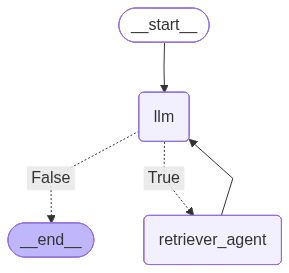

In [11]:
# ===== 11. 可视化图结构 =====
# 这一格不是 RAG 功能必需的，只是为了帮助你看懂图的结构。
# draw_mermaid_png() 会把 LangGraph 转成 Mermaid 图并渲染成图片。
from IPython.display import Image, display

display(Image(rag_agent.get_graph().draw_mermaid_png()))


In [12]:
# ===== 12. 交互式运行 RAG Agent =====
def running_agent():
    """循环读取用户问题，调用 RAG Agent，并打印最终回答。"""
    print("\n=== RAG AGENT ===")

    while True:
        # input() 会在 notebook 中等待你输入问题。
        # 输入 exit 时退出循环。
        user_question = input("\n请输入你的问题（输入 'exit' 退出）：")
        if user_question.lower() == "exit":
            print("退出 RAG Agent。")
            break

        # 把用户问题包装成 HumanMessage。
        # LangGraph 的 messages 状态里保存的是消息对象，而不是普通字符串。
        messages = [HumanMessage(content=user_question)]

        # 调用编译后的 RAG Agent。
        # 执行过程中可能发生：
        # 1. llm 生成 tool_call；
        # 2. retriever_agent 执行 retriver_tool；
        # 3. llm 基于 ToolMessage 生成最终回答。
        result = rag_agent.invoke({"messages": messages})

        # result 是最终状态。
        # result["messages"][-1] 通常是最后一条 AIMessage，也就是最终回答。
        print(f"\nAgent 的回答:\n{result['messages'][-1].content}")


# 运行交互式 Agent。
# 如果你只想导入/调试前面的函数，可以先注释掉这一行，避免 notebook 立刻进入 input()。
running_agent()



=== RAG AGENT ===

Agent 的回答:
你好！有什么我可以帮您的吗？
执行工具调用: retriver_tool with query: 2024年股票市场表现较好的股票
结果长度: 4873
工具执行完成，返回到 LLM 进行下一轮处理

Agent 的回答:
2024年股票市场表现非常强劲，尤其是科技板块表现突出。以下是一些在2024年表现较好的股票和行业趋势：

1. **科技巨头**：像 **Apple（苹果）**、**Alphabet（谷歌母公司）** 和 **Meta（脸书母公司）** 等大型科技公司表现优异。

2. **新兴科技公司**：与技术创新相关的公司，特别是人工智能（AI）、芯片和软件领域的公司，取得了显著的增长。

3. **转型技术趋势**：投资者特别青睐与以下技术趋势相关的公司：
   - **人工智能（AI）**
   - **云计算**
   - **量子技术**

2024年，标普500指数上涨了约25%，主要受到这些科技公司的推动。市场对未来增长的乐观情绪也使得许多领先股票的估值大幅提高。

如果你对某些具体股票或行业有兴趣，可以进一步探讨！
退出 RAG Agent。
